In [3]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
load_dotenv()

True

In [4]:
model = ChatOpenAI(model='gpt-4o-mini')

In [5]:
class sentimentSchema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="Sentiment of the review")

In [21]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [22]:
structured_model1 =  model.with_structured_output(sentimentSchema)
structured_model2 =  model.with_structured_output(DiagnosisSchema)

In [23]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    response:str

In [31]:
def find_sentiment(state:ReviewState):
    review = state["review"]
    prompt = f"for the following review,find out the sentiment \n {review}"
    sentiment = structured_model1.invoke(prompt).sentiment
    return {"sentiment": sentiment}

def check_sentiment(state:ReviewState) -> Literal["positive_response","run_diagnosis"]:
    sentiment = state["sentiment"]
    if sentiment =="positive":
        return "positive_response"
    else:
        return "run_diagnosis"
    
def positive_response(state:ReviewState):
    review = state["review"]
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{review}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state:ReviewState):
    review= state["review"]
    prompt = f"""Diagnose this negative review:\n\n{review}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    #model_dump() converts the pydantic model output to a dictionary
    return {"diagnosis": response.model_dump()}

def negative_response(state: ReviewState):
    diagnosis = state["diagnosis"]
    issue_type = diagnosis["issue_type"]
    tone = diagnosis["tone"]
    urgency = diagnosis["urgency"]
    prompt = f"""You are a support assistant.
The user had a {issue_type} issue, sounded {tone}, and marked urgency as {urgency}.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {"response": response}


In [32]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("positive_response",END)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)

workflow = graph.compile()

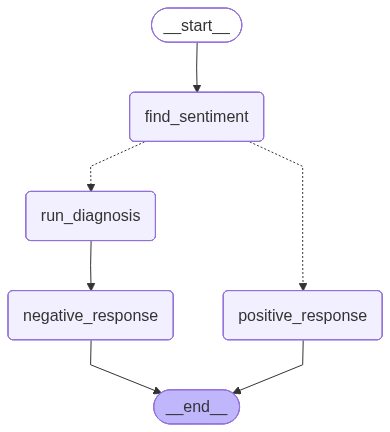

In [33]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(initial_state)